# Coupled CARMA validation


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.stats import norm, norminvgauss, kstest, probplot, pearsonr, spearmanr
from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Coupled CARMA model, following Gachon & Karbach:
#   dZ_T = A_T Z_T dt + sigma_T e_T dW_T,         T_t = b_T' Z_T
#   dZ_X = A_X Z_X dt + lambda sigma_T e_X dW_T
#          + sigma_J e_X dW_X,                    X_t = b_X' Z_X
# The CARMA companion convention is the same as in notebooks 06/07.

def load_named_params(path):
    df = pd.read_csv(path)
    name_col = "name" if "name" in df.columns else df.columns[0]
    value_col = "value" if "value" in df.columns else df.columns[1]
    return dict(zip(df[name_col].astype(str), df[value_col].astype(float)))

def build_carma_from_params(path):
    params = load_named_params(path)
    a_names = sorted([k for k in params if k.startswith("a")], key=lambda s: int(s[1:]))
    b_names = sorted([k for k in params if k.startswith("b")], key=lambda s: int(s[1:]))
    p = len(a_names)
    A = np.zeros((p, p), dtype=float)
    if p > 1:
        A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -np.array([params[f"a{i}"] for i in range(p, 0, -1)], dtype=float)
    b = np.zeros(p, dtype=float)
    for name in b_names:
        j = int(name[1:])
        if j < p:
            b[j] = params[name]
    e = np.zeros(p, dtype=float)
    e[-1] = 1.0
    return A, b, e, float(params["sig"]), params

A_T, b_T, e_T, sigma_T, params_T = build_carma_from_params("../data/kalman/temp_carma_params.csv")
A_X, b_X, e_X, sigma_X_marginal, params_X = build_carma_from_params("../data/kalman/price_carma_params.csv")

p_T, p_X = A_T.shape[0], A_X.shape[0]
h = 1.0  # fitted CARMA parameters are on the hourly scale

carma_parameter_table = pd.DataFrame({
    "p": [p_T, p_X],
    "sigma": [sigma_T, sigma_X_marginal],
    "b": [np.round(b_T, 6), np.round(b_X, 6)],
    "A_eigenvalues": [np.round(np.linalg.eigvals(A_T), 6), np.round(np.linalg.eigvals(A_X), 6)],
}, index=["temperature", "price"])
display(carma_parameter_table)


,p,sigma,b,A_eigenvalues
temperature,2,0.769633,"[1.0, 0.584421]","[-0.030773, -0.80383]"
price,3,0.023063,"[1.0, -1.691075, 0.085606]","[-0.101312, -1.710333, -0.930092]"


In [27]:
# State-space helpers

def van_loan(A, G, dt):
    """Discrete F and Q for dZ = A Z dt + G dW using Van Loan discretization."""
    n = A.shape[0]
    M = np.block([[A, G @ G.T], [np.zeros((n, n)), -A.T]]) * float(dt)
    E = expm(M)
    F = E[:n, :n]
    Q = E[:n, n:] @ F.T
    return F, 0.5 * (Q + Q.T)

def stationary_covariance(A, G):
    """Continuous-time stationary covariance, used only for Kalman initialisation."""
    P = solve_continuous_lyapunov(A, -(G @ G.T))
    return 0.5 * (P + P.T)

def cross_covariance_kernel(A_T, A_X, e_T, e_X, sigma_T, dt):
    """K_TX = sigma_T^2 int_0^dt exp(A_T s)e_T e_X' exp(A_X' s) ds."""
    p_T, p_X = len(e_T), len(e_X)
    A = np.zeros((p_T + p_X, p_T + p_X))
    A[:p_T, :p_T] = A_T
    A[p_T:, p_T:] = A_X
    G = np.zeros((p_T + p_X, 1))
    G[:p_T, 0] = sigma_T * e_T
    G[p_T:, 0] = sigma_T * e_X
    _, Q = van_loan(A, G, dt)
    return Q[:p_T, p_T:]

def kf_scalar(y, A, G, H, dt, x0=None, P0=None, obs_noise=1e-8):
    """Scalar-output Kalman filter for marginal CARMA state recovery."""
    n, m = len(y), A.shape[0]
    h_vec = np.asarray(H, dtype=float).reshape(-1)
    x = np.zeros(m) if x0 is None else np.asarray(x0, dtype=float).copy()
    P = stationary_covariance(A, G) + np.eye(m) * 1e-6 if P0 is None else P0.copy()
    F, Q = van_loan(A, G, dt)
    x_filt = np.zeros((n, m))
    innov = np.zeros(n)
    S_arr = np.zeros(n)
    loglik = 0.0
    for k in range(n):
        if k > 0:
            x = F @ x
            P = F @ P @ F.T + Q
        mu = float(h_vec @ x)
        S = float(h_vec @ P @ h_vec) + obs_noise
        v = y[k] - mu
        K = (P @ h_vec) / S
        x = x + K * v
        P = (np.eye(m) - np.outer(K, h_vec)) @ P
        P = 0.5 * (P + P.T)
        x_filt[k] = x
        innov[k] = v
        S_arr[k] = S
        loglik += -0.5 * (np.log(2 * np.pi * S) + v**2 / S)
    return dict(F=F, Q=Q, x_filt=x_filt, innov=innov, S=S_arr, loglik=float(loglik))



In [28]:
# Load deseasonalised residuals and recovered Levy increments.

def read_residual_series(path, value_col):
    df = pd.read_csv(path, parse_dates=["datetime"])
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
    df = df[["datetime", value_col]].dropna().sort_values("datetime")
    df = df.set_index("datetime")
    df[value_col] = df[value_col].astype(float)
    return df

temp_df = read_residual_series("../data/deseasonalised/temp_resid.csv", "temp_deseasoned")
price_df = read_residual_series("../data/deseasonalised/price_resid.csv", "price_deseasoned")

# Marginal filters have no intercept; work with zero-mean deseasonalised residuals.
temp_mean = float(temp_df["temp_deseasoned"].mean())
price_mean = float(price_df["price_deseasoned"].mean())
temp_df["T"] = temp_df["temp_deseasoned"] - temp_mean
price_df["X"] = price_df["price_deseasoned"] - price_mean

time_T = temp_df.index
time_X = price_df.index
y_T = temp_df["T"].to_numpy(float)
y_X = price_df["X"].to_numpy(float)

common_idx = time_T.intersection(time_X).sort_values()
y_T_c = temp_df.loc[common_idx, "T"].to_numpy(float)
y_X_c = price_df.loc[common_idx, "X"].to_numpy(float)
y_obs = np.column_stack([y_T_c, y_X_c])

dL_T_df = pd.read_csv("../data/levy/temp_levy_increments.csv", parse_dates=["datetime"])
dL_T_df["datetime"] = pd.to_datetime(dL_T_df["datetime"], utc=True)
dL_T_df = dL_T_df.rename(columns={"dL": "dL_T"})[["datetime", "dL_T"]]

dL_X_df = pd.read_csv("../data/levy/price_levy_increments.csv")
if "datetime" in dL_X_df.columns:
    dL_X_df["datetime"] = pd.to_datetime(dL_X_df["datetime"], utc=True)
else:
    dL_X_df = dL_X_df.copy()
    dL_X_df["datetime"] = time_X[1:len(dL_X_df) + 1].to_numpy()
dL_X_df = dL_X_df.rename(columns={"dL": "dL_X"})[["datetime", "dL_X"]]

levy_df = dL_T_df.merge(dL_X_df, on="datetime", how="inner").sort_values("datetime")
dL_T = levy_df["dL_T"].to_numpy(float)
dL_X = levy_df["dL_X"].to_numpy(float)

data_alignment_table = pd.DataFrame({
    "n": [len(y_T), len(y_X), len(common_idx), len(levy_df)],
    "start": [time_T.min(), time_X.min(), common_idx.min(), levy_df["datetime"].min()],
    "end": [time_T.max(), time_X.max(), common_idx.max(), levy_df["datetime"].max()],
    "mean_removed": [temp_mean, price_mean, np.nan, np.nan],
}, index=["temperature_residuals", "price_residuals", "joint_observations", "aligned_increments"])
increment_moments = pd.DataFrame({
    "mean": [dL_T.mean(), dL_X.mean()],
    "std": [dL_T.std(ddof=1), dL_X.std(ddof=1)],
}, index=["dL_T", "dL_X"])
display(data_alignment_table)
display(increment_moments.round(8))


,n,start,end,mean_removed
temperature_residuals,52608,2020-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,6.513169e-10
price_residuals,26281,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2.072228e-05
joint_observations,26281,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,NaN
aligned_increments,26280,2023-01-01 01:00:00+00:00,2025-12-31 00:00:00+00:00,NaN


,mean,std
dL_T,0.004627,0.961933
dL_X,0.000019,0.638597


## Temperature driver fit


In [29]:
mu_T = dL_T.mean()
sig_T = dL_T.std(ddof=1)
n_T = len(dL_T)

ll_gauss_T = float(norm.logpdf(dL_T, mu_T, sig_T).sum())
aic_g_T = -2 * ll_gauss_T + 2 * 2
bic_g_T = -2 * ll_gauss_T + 2 * np.log(n_T)

try:
    a_n, b_n, loc_n, sc_n = norminvgauss.fit(dL_T, method="MLE")
    ll_nig_T = float(norminvgauss.logpdf(dL_T, a_n, b_n, loc=loc_n, scale=sc_n).sum())
    aic_nig_T = -2 * ll_nig_T + 2 * 4
    bic_nig_T = -2 * ll_nig_T + 4 * np.log(n_T)
    nig_ok = True
except Exception:
    a_n = b_n = loc_n = sc_n = np.nan
    ll_nig_T = aic_nig_T = bic_nig_T = np.nan
    nig_ok = False

ks_stat, ks_p = kstest(dL_T, lambda x: norm.cdf(x, mu_T, sig_T))

temp_driver_fit = pd.DataFrame({
    "loglik": [ll_gauss_T, ll_nig_T],
    "n_params": [2, 4],
    "AIC": [aic_g_T, aic_nig_T],
    "BIC": [bic_g_T, bic_nig_T],
}, index=["Gaussian", "NIG"])
temp_driver_moments = pd.DataFrame({
    "n": [n_T],
    "mean": [mu_T],
    "std": [sig_T],
    "ks_stat": [ks_stat],
    "ks_pvalue": [ks_p],
}, index=["dL_T"])

display(temp_driver_fit.round(6))
display(temp_driver_moments.round(6))


,loglik,n_params,AIC,BIC
Gaussian,-36269.276022,2,72542.552044,72558.905171
NIG,-33242.495503,4,66492.991005,66525.697259


,n,mean,std,ks_stat,ks_pvalue
dL_T,26280,0.004627,0.961933,0.074651,0.0


## Price driver fit


,loglik,n_params,AIC,BIC,delta_AIC
Gaussian,-25503.106350,2,51010.212699,51026.565826,13590.183404
NIG,-18706.014647,4,37420.029295,37452.735549,0.000000


,a,b,loc,scale
NIG,0.32884,-0.031766,0.032524,0.334887


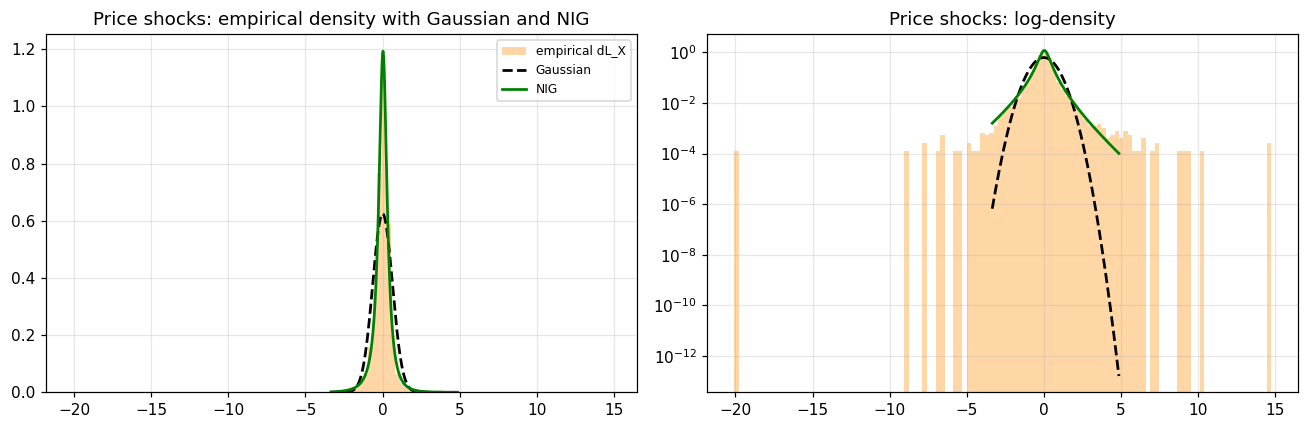

In [30]:
n_X = len(dL_X)
mu_g, sg = norm.fit(dL_X)
ll_g = float(norm.logpdf(dL_X, mu_g, sg).sum())
aic_g_X = -2 * ll_g + 2 * 2
bic_g_X = -2 * ll_g + 2 * np.log(n_X)

try:
    ax_n, bx_n, lx_n, sx_n = norminvgauss.fit(dL_X, method="MLE")
    ll_nig_X = float(norminvgauss.logpdf(dL_X, ax_n, bx_n, loc=lx_n, scale=sx_n).sum())
    aic_nig_X = -2 * ll_nig_X + 2 * 4
    bic_nig_X = -2 * ll_nig_X + 4 * np.log(n_X)
    nig_ok_X = True
except Exception:
    ax_n = bx_n = lx_n = sx_n = np.nan
    ll_nig_X = aic_nig_X = bic_nig_X = np.nan
    nig_ok_X = False

df_aic = pd.DataFrame({
    "loglik": [ll_g, ll_nig_X],
    "n_params": [2, 4],
    "AIC": [aic_g_X, aic_nig_X],
    "BIC": [bic_g_X, bic_nig_X],
}, index=["Gaussian", "NIG"])
df_aic["delta_AIC"] = df_aic["AIC"] - df_aic["AIC"].min()

display(df_aic.round(6))
if nig_ok_X:
    display(pd.DataFrame({
        "a": [ax_n],
        "b": [bx_n],
        "loc": [lx_n],
        "scale": [sx_n],
    }, index=["NIG"]).round(6))

x_grid = np.linspace(np.quantile(dL_X, 0.001), np.quantile(dL_X, 0.999), 600)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dL_X, bins=120, density=True, color="darkorange", alpha=0.35, label="empirical dL_X")
axes[0].plot(x_grid, norm.pdf(x_grid, mu_g, sg), "k--", lw=1.8, label="Gaussian")
if nig_ok_X:
    axes[0].plot(x_grid, norminvgauss.pdf(x_grid, ax_n, bx_n, loc=lx_n, scale=sx_n), "g-", lw=1.8, label="NIG")
axes[0].set_title("Price shocks: empirical density with Gaussian and NIG")
axes[0].legend(fontsize=8)

axes[1].hist(dL_X, bins=120, density=True, color="darkorange", alpha=0.35, log=True)
axes[1].plot(x_grid, np.maximum(norm.pdf(x_grid, mu_g, sg), 1e-300), "k--", lw=1.8)
if nig_ok_X:
    axes[1].plot(x_grid, np.maximum(norminvgauss.pdf(x_grid, ax_n, bx_n, loc=lx_n, scale=sx_n), 1e-300), "g-", lw=1.8)
axes[1].set_title("Price shocks: log-density")
plt.tight_layout()
plt.show()


## Constant lambda

The paper identifies $\lambda$ from $\operatorname{Cov}(R_T,R_X)$. In the model these residuals are Brownian/Lévy increments with zero mean, so the population covariance equals $\mathbb{E}[R_T R_X']$. Empirically, the estimate below uses the centered covariance and reports the uncentered moment only as a diagnostic.


In [31]:
G_T = (sigma_T * e_T).reshape(-1, 1)
G_X_marginal = (sigma_X_marginal * e_X).reshape(-1, 1)
H_T = b_T.reshape(1, -1)
H_X = b_X.reshape(1, -1)

res_kf_T = kf_scalar(y_T, A_T, G_T, H_T, h)
res_kf_X = kf_scalar(y_X, A_X, G_X_marginal, H_X, h)

xT = res_kf_T["x_filt"]
xX = res_kf_X["x_filt"]
FT, FX = res_kf_T["F"], res_kf_X["F"]
R_T = xT[1:] - (FT @ xT[:-1].T).T
R_X = xX[1:] - (FX @ xX[:-1].T).T

idx_T = pd.DatetimeIndex(time_T[1:])
idx_X = pd.DatetimeIndex(time_X[1:])
common_resid_idx = idx_T.intersection(idx_X).sort_values()
loc_T = idx_T.get_indexer(common_resid_idx)
loc_X = idx_X.get_indexer(common_resid_idx)
valid = (loc_T >= 0) & (loc_X >= 0)
common_resid_idx = common_resid_idx[valid]
R_T_c = R_T[loc_T[valid]]
R_X_c = R_X[loc_X[valid]]
n_c = len(common_resid_idx)

def centered_cross_moment_matrix(X, Y):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Y - Y.mean(axis=0, keepdims=True)
    return (Xc.T @ Yc) / len(X)

D_TX_hat = centered_cross_moment_matrix(R_T_c, R_X_c)
D_TX_hat_uncentered = (R_T_c.T @ R_X_c) / n_c
K_TX = cross_covariance_kernel(A_T, A_X, e_T, e_X, sigma_T, h)

num = float(b_T @ D_TX_hat @ b_X)
num_uncentered = float(b_T @ D_TX_hat_uncentered @ b_X)
denom_lam = float(b_T @ K_TX @ b_X)
lambda_hat = num / denom_lam
lambda_uncentered = num_uncentered / denom_lam
lambda_centering_difference = lambda_hat - lambda_uncentered
lambda_centering_relative_diff_pct = float(
    100 * lambda_centering_difference / lambda_hat
) if lambda_hat != 0 else np.nan

r_T_marginal_obs = R_T_c @ b_T
r_X_marginal_obs = R_X_c @ b_X
var_r_T = float(np.mean((r_T_marginal_obs - r_T_marginal_obs.mean()) ** 2))
var_r_X = float(np.mean((r_X_marginal_obs - r_X_marginal_obs.mean()) ** 2))
R2_lam = float(num**2 / (var_r_T * var_r_X))

lambda_estimate = pd.DataFrame({
    "n_common": [n_c],
    "numerator_centered": [num],
    "numerator_uncentered": [num_uncentered],
    "denominator": [denom_lam],
    "lambda_hat": [lambda_hat],
    "lambda_uncentered": [lambda_uncentered],
    "lambda_centering_difference": [lambda_centering_difference],
    "lambda_centering_relative_diff_pct": [lambda_centering_relative_diff_pct],
    "mean_r_T": [float(r_T_marginal_obs.mean())],
    "mean_r_X": [float(r_X_marginal_obs.mean())],
    "R2_output_cross_cov": [R2_lam],
    "temp_marginal_loglik": [res_kf_T["loglik"]],
    "price_marginal_loglik": [res_kf_X["loglik"]],
}, index=["global"])
display(lambda_estimate.round(8))


,n_common,numerator_centered,numerator_uncentered,denominator,lambda_hat,lambda_uncentered,lambda_centering_difference,lambda_centering_relative_diff_pct,mean_r_T,mean_r_X,R2_output_cross_cov,temp_marginal_loglik,price_marginal_loglik
global,26280,-0.000208,-0.000208,-0.118809,0.001749,0.001748,3.000000e-08,0.001513,0.002815,0.000001,0.000832,-48516.22037,78288.683595


In [32]:
rng = np.random.default_rng(42)
lam_boot = np.empty(500)
for j in range(len(lam_boot)):
    idx = rng.integers(0, n_c, size=n_c)
    D_boot = centered_cross_moment_matrix(R_T_c[idx], R_X_c[idx])
    lam_boot[j] = (b_T @ D_boot @ b_X) / denom_lam

se_lam = float(lam_boot.std(ddof=1))
ci_lam = np.percentile(lam_boot, [2.5, 97.5])
t_stat = float(lambda_hat / se_lam)

lambda_uncertainty = pd.DataFrame({
    "lambda_hat": [lambda_hat],
    "se": [se_lam],
    "ci_95_lo": [ci_lam[0]],
    "ci_95_hi": [ci_lam[1]],
    "t_stat": [t_stat],
    "lambda_uncentered": [lambda_uncentered],
    "lambda_centering_difference": [lambda_centering_difference],
    "lambda_centering_relative_diff_pct": [lambda_centering_relative_diff_pct],
    "R2_output_cross_cov": [R2_lam],
    "n_common": [n_c],
}, index=["global"])
display(lambda_uncertainty.round(8))

pd.DataFrame({
    "lambda_hat": [lambda_hat],
    "se": [se_lam],
    "ci_lo": [ci_lam[0]],
    "ci_hi": [ci_lam[1]],
    "t_stat": [t_stat],
    "R2": [R2_lam],
    "n_common": [n_c],
    "lambda_uncentered": [lambda_uncentered],
    "lambda_centering_difference": [lambda_centering_difference],
    "lambda_centering_relative_diff_pct": [lambda_centering_relative_diff_pct],
    "numerator_centered": [num],
    "numerator_uncentered": [num_uncentered],
    "denominator": [denom_lam],
    "mean_r_T": [float(r_T_marginal_obs.mean())],
    "mean_r_X": [float(r_X_marginal_obs.mean())],
}).to_csv("../data/levy/coupling_estimate.csv", index=False)


,lambda_hat,se,ci_95_lo,ci_95_hi,t_stat,lambda_uncentered,lambda_centering_difference,lambda_centering_relative_diff_pct,R2_output_cross_cov,n_common
global,0.001749,0.000386,0.000948,0.002427,4.531292,0.001748,3.000000e-08,0.001513,0.000832,26280


## Price noise scale


In [33]:
# Raw idiosyncratic price increment
dL_J = dL_X - lambda_hat * dL_T
std_dL_J = float(np.std(dL_J, ddof=1))

# sigma_J in Z_X state units via marginal variance identity:
#   (lambda*sigma_T)^2 * var(dL_T) + sigma_J^2 * var(dL_J) = sigma_X_marginal^2
# lambda is tiny (0.0017) so the temperature contribution is negligible,
# but we carry it for rigour.
sigma_J = float(
    np.sqrt(max(sigma_X_marginal**2 - (lambda_hat * sigma_T)**2, 0.0)) / std_dL_J
)

temp_share = float(100.0 * (lambda_hat * sigma_T)**2 / sigma_X_marginal**2)

sigma_table = pd.DataFrame({
    "sigma_X_marginal": [sigma_X_marginal],
    "lambda_sigma_T": [lambda_hat * sigma_T],
    "std_dL_J": [std_dL_J],
    "sigma_J": [sigma_J],
    "temp_variance_share_pct": [temp_share],
}, index=["marginal_variance_identity"])
display(sigma_table.round(8))

,sigma_X_marginal,lambda_sigma_T,std_dL_J,sigma_J,temp_variance_share_pct
marginal_variance_identity,0.023063,0.001346,0.638661,0.03605,0.340458


## Idiosyncratic price driver distribution

The coupled model increment for the price state is

$$dZ_X = A_X Z_X\,dt + \lambda\sigma_T e_X\,dL_T + \sigma_J e_X\,dL_J$$

where $dL_T \sim \text{Gaussian}$ and $dL_J \sim \text{NIG}$ are independent. The idiosyncratic driver is extracted by removing the temperature contribution from the recovered price shocks:

$$dL_J = dL_X - \hat\lambda\, dL_T.$$

Since $\hat\lambda \approx 0.0017$ is tiny, $dL_J \approx dL_X$. The NIG distribution is fitted directly to the raw $dL_J$ series (no normalisation required). The state-space scaling $\sigma_J$ is recovered from the marginal variance identity:

$$(\lambda\sigma_T)^2 \operatorname{Var}(dL_T) + \sigma_J^2 \operatorname{Var}(dL_J) = \sigma_X^2$$

$$\Rightarrow \sigma_J = \frac{\sqrt{\sigma_X^2 - (\lambda\sigma_T)^2}}{\operatorname{std}(dL_J)}.$$

In [34]:
# dL_J already defined above as dL_X - lambda_hat * dL_T (raw, no normalisation)

idiosyncratic_increments = pd.DataFrame({
    "datetime": levy_df["datetime"].to_numpy(),
    "dL_J": dL_J,
    "dL_X": dL_X,
    "lambda_dL_T": lambda_hat * dL_T,
    "sigma_J_dL_J": sigma_J * dL_J,
})
idiosyncratic_increments.to_csv(
    "../data/levy/price_idiosyncratic_levy_increments.csv", index=False
)

mu_J, sg_J = norm.fit(dL_J)
ll_g_J = float(norm.logpdf(dL_J, mu_J, sg_J).sum())
aic_g_J = -2 * ll_g_J + 2 * 2
bic_g_J = -2 * ll_g_J + 2 * np.log(len(dL_J))

try:
    aJ_n, bJ_n, lJ_n, sJ_n = norminvgauss.fit(dL_J, method="MLE")
    ll_nig_J = float(norminvgauss.logpdf(dL_J, aJ_n, bJ_n, loc=lJ_n, scale=sJ_n).sum())
    aic_nig_J = -2 * ll_nig_J + 2 * 4
    bic_nig_J = -2 * ll_nig_J + 4 * np.log(len(dL_J))
    nig_ok_J = True
except Exception:
    aJ_n = bJ_n = lJ_n = sJ_n = np.nan
    ll_nig_J = aic_nig_J = bic_nig_J = np.nan
    nig_ok_J = False

sk_J = float(pd.Series(dL_J).skew())
ku_J = float(pd.Series(dL_J).kurtosis() + 3)

idiosyncratic_driver_fit = pd.DataFrame({
    "series": ["price_idiosyncratic_driver", "price_idiosyncratic_driver"],
    "model": ["Gaussian", "NIG"],
    "loglik": [ll_g_J, ll_nig_J],
    "n_params": [2, 4],
    "AIC": [aic_g_J, aic_nig_J],
    "BIC": [bic_g_J, bic_nig_J],
})
idiosyncratic_driver_fit["delta_AIC"] = (
    idiosyncratic_driver_fit["AIC"] - idiosyncratic_driver_fit["AIC"].min()
)

idiosyncratic_driver_params = pd.DataFrame([
    {"series": "price_idiosyncratic_driver", "model": "Gaussian", "parameter": "mu", "value": mu_J},
    {"series": "price_idiosyncratic_driver", "model": "Gaussian", "parameter": "sigma", "value": sg_J},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "scipy_a", "value": aJ_n},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "scipy_b", "value": bJ_n},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "loc", "value": lJ_n},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "scale", "value": sJ_n},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "alpha", "value": aJ_n / sJ_n},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "beta", "value": bJ_n / sJ_n},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "delta", "value": sJ_n},
    {"series": "price_idiosyncratic_driver", "model": "NIG", "parameter": "mu", "value": lJ_n},
])

idiosyncratic_driver_moments = pd.DataFrame({
    "series": ["price_idiosyncratic_driver"],
    "n": [len(dL_J)],
    "mean": [float(np.mean(dL_J))],
    "std": [float(np.std(dL_J, ddof=1))],
    "skew": [sk_J],
    "kurtosis": [ku_J],
})

# Algebraic identity: dL_J + lambda_hat * dL_T = dL_X (exact by construction)
reconstructed = dL_J + lambda_hat * dL_T
decomposition_check = pd.DataFrame({
    "n": [len(dL_J)],
    "mean_dL_J": [float(np.mean(dL_J))],
    "std_dL_J": [float(np.std(dL_J, ddof=1))],
    "corr_dL_T_dL_J": [float(pearsonr(dL_T, dL_J).statistic)],
    "std_lambda_dL_T": [float(np.std(lambda_hat * dL_T, ddof=1))],
    "std_sigmaJ_dLJ": [float(np.std(sigma_J * dL_J, ddof=1))],
    "std_reconstructed_dL_X": [float(np.std(reconstructed, ddof=1))],
    "std_dL_X": [float(np.std(dL_X, ddof=1))],
    "max_reconstruction_error": [float(np.max(np.abs(reconstructed - dL_X)))],
}, index=["price_idiosyncratic_driver"])

display(idiosyncratic_driver_fit.round(6))
display(idiosyncratic_driver_params.pivot_table(
    index=["series", "model"], columns="parameter", values="value", aggfunc="first"
).round(6))
display(idiosyncratic_driver_moments.round(6))
display(decomposition_check.round(8))

# Simulation-ready exports: marginal drivers plus the idiosyncratic price driver.
driver_fit = pd.DataFrame([
    {"series": "temperature_driver", "model": "Gaussian", "loglik": ll_gauss_T, "n_params": 2, "AIC": aic_g_T, "BIC": bic_g_T},
    {"series": "temperature_driver", "model": "NIG", "loglik": ll_nig_T, "n_params": 4, "AIC": aic_nig_T, "BIC": bic_nig_T},
    {"series": "price_marginal_driver", "model": "Gaussian", "loglik": ll_g, "n_params": 2, "AIC": aic_g_X, "BIC": bic_g_X},
    {"series": "price_marginal_driver", "model": "NIG", "loglik": ll_nig_X, "n_params": 4, "AIC": aic_nig_X, "BIC": bic_nig_X},
])
driver_fit = pd.concat([driver_fit, idiosyncratic_driver_fit], ignore_index=True)
driver_fit["delta_AIC"] = driver_fit["AIC"] - driver_fit.groupby("series")["AIC"].transform("min")

driver_params = pd.DataFrame([
    {"series": "temperature_driver", "model": "Gaussian", "parameter": "mu", "value": mu_T},
    {"series": "temperature_driver", "model": "Gaussian", "parameter": "sigma", "value": sig_T},
    {"series": "temperature_driver", "model": "NIG", "parameter": "scipy_a", "value": a_n},
    {"series": "temperature_driver", "model": "NIG", "parameter": "scipy_b", "value": b_n},
    {"series": "temperature_driver", "model": "NIG", "parameter": "loc", "value": loc_n},
    {"series": "temperature_driver", "model": "NIG", "parameter": "scale", "value": sc_n},
    {"series": "temperature_driver", "model": "NIG", "parameter": "alpha", "value": a_n / sc_n},
    {"series": "temperature_driver", "model": "NIG", "parameter": "beta", "value": b_n / sc_n},
    {"series": "temperature_driver", "model": "NIG", "parameter": "delta", "value": sc_n},
    {"series": "temperature_driver", "model": "NIG", "parameter": "mu", "value": loc_n},
    {"series": "price_marginal_driver", "model": "Gaussian", "parameter": "mu", "value": mu_g},
    {"series": "price_marginal_driver", "model": "Gaussian", "parameter": "sigma", "value": sg},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "scipy_a", "value": ax_n},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "scipy_b", "value": bx_n},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "loc", "value": lx_n},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "scale", "value": sx_n},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "alpha", "value": ax_n / sx_n},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "beta", "value": bx_n / sx_n},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "delta", "value": sx_n},
    {"series": "price_marginal_driver", "model": "NIG", "parameter": "mu", "value": lx_n},
])
driver_params = pd.concat([driver_params, idiosyncratic_driver_params], ignore_index=True)

driver_moments = pd.DataFrame([
    {"series": "temperature_driver", "n": len(dL_T), "mean": float(np.mean(dL_T)), "std": float(np.std(dL_T, ddof=1)), "skew": float(pd.Series(dL_T).skew()), "kurtosis": float(pd.Series(dL_T).kurtosis() + 3)},
    {"series": "price_marginal_driver", "n": len(dL_X), "mean": float(np.mean(dL_X)), "std": float(np.std(dL_X, ddof=1)), "skew": float(pd.Series(dL_X).skew()), "kurtosis": float(pd.Series(dL_X).kurtosis() + 3)},
])
driver_moments = pd.concat([driver_moments, idiosyncratic_driver_moments], ignore_index=True)

driver_fit.to_csv("../data/levy/carma_levy_driver_fit.csv", index=False)
driver_params.to_csv("../data/levy/carma_levy_driver_params.csv", index=False)
driver_moments.to_csv("../data/levy/carma_levy_driver_moments.csv", index=False)
idiosyncratic_driver_fit.to_csv("../data/levy/price_idiosyncratic_driver_fit.csv", index=False)
idiosyncratic_driver_params.to_csv("../data/levy/price_idiosyncratic_driver_params.csv", index=False)
idiosyncratic_driver_moments.to_csv("../data/levy/price_idiosyncratic_driver_moments.csv", index=False)
decomposition_check.to_csv("../data/levy/price_idiosyncratic_decomposition_check.csv")

,series,model,loglik,n_params,AIC,BIC,delta_AIC
0,price_idiosyncratic_driver,Gaussian,-25505.738405,2,51015.476809,51031.829936,13585.856104
1,price_idiosyncratic_driver,NIG,-18710.810353,4,37429.620705,37462.326959,0.000000


parameter                               alpha     beta     delta       loc  \
series                     model                                             
price_idiosyncratic_driver Gaussian       NaN      NaN       NaN       NaN   
                           NIG       0.982157 -0.09494  0.335008  0.032544   

parameter                                  mu     scale   scipy_a   scipy_b  \
series                     model                                              
price_idiosyncratic_driver Gaussian  0.000011       NaN       NaN       NaN   
                           NIG       0.032544  0.335008  0.329031 -0.031806   

parameter                               sigma  
series                     model               
price_idiosyncratic_driver Gaussian  0.638649  
                           NIG            NaN

,series,n,mean,std,skew,kurtosis
0,price_idiosyncratic_driver,26280,0.000011,0.638661,0.411693,84.287771


,n,mean_dL_J,std_dL_J,corr_dL_T_dL_J,std_lambda_dL_T,std_sigmaJ_dLJ,std_reconstructed_dL_X,std_dL_X,max_reconstruction_error
price_idiosyncratic_driver,26280,0.000011,0.638661,-0.039343,0.001682,0.023024,0.638597,0.638597,0.0


## Joint matrices


In [35]:
p = p_T + p_X

A_joint = np.zeros((p, p))
A_joint[:p_T, :p_T] = A_T
A_joint[p_T:, p_T:] = A_X

H_joint = np.zeros((2, p))
H_joint[0, :p_T] = b_T
H_joint[1, p_T:] = b_X

# Structural G (unit-variance drivers) — used for simulation and lambda identification.
G_joint = np.zeros((p, 2))
G_joint[:p_T, 0] = sigma_T * e_T
G_joint[p_T:, 0] = lambda_hat * sigma_T * e_X
G_joint[p_T:, 1] = sigma_J * e_X

# G scaled by actual driver stds for Kalman filter Q.
# dL_T ~ Gaussian with std = sig_T,  dL_J ~ NIG with std = std_dL_J.
# Q_actual = integral exp(As) G diag(sig_T^2, std_dL_J^2) G' exp(A's) ds
#          = van_loan(A, G * diag(sig_T, std_dL_J), h)[1]
G_joint_kf = G_joint * np.array([sig_T, std_dL_J])[np.newaxis, :]
F_joint, Q_joint = van_loan(A_joint, G_joint_kf, h)

joint_matrix_check = pd.DataFrame({
    "state_dim": [p],
    "obs_dim": [2],
    "noise_dim": [2],
    "Q_T_projected": [float(b_T @ Q_joint[:p_T, :p_T] @ b_T)],
    "Q_X_projected": [float(b_X @ Q_joint[p_T:, p_T:] @ b_X)],
    "sigma_X_marginal_sq": [float(sigma_X_marginal**2)],
    "Q_cross_projected": [float(b_T @ Q_joint[:p_T, p_T:] @ b_X)],
    "lambda_denom": [float(lambda_hat * denom_lam)],
}, index=["joint"])
display(joint_matrix_check.round(8))

,state_dim,obs_dim,noise_dim,Q_T_projected,Q_X_projected,sigma_X_marginal_sq,Q_cross_projected,lambda_denom
joint,5,2,2,0.338374,0.000038,0.000532,-0.000192,-0.000208


In [36]:
def joint_kf(y_obs, times, A, G, H, R_obs, x0=None, P0=None):
    """Joint Kalman filter with one-step-ahead predictions and variable timestamps."""
    n, p = len(y_obs), A.shape[0]
    nobs = H.shape[0]
    x = np.zeros(p) if x0 is None else np.asarray(x0, dtype=float).copy()
    P = stationary_covariance(A, G) + np.eye(p) * 1e-6 if P0 is None else P0.copy()
    y_pred = np.zeros((n, nobs))
    innov = np.zeros((n, nobs))
    S_arr = np.zeros((n, nobs, nobs))
    x_filt = np.zeros((n, p))
    loglik = 0.0
    cache = {}
    I = np.eye(p)

    for k in range(n):
        if k > 0:
            dt = float((times[k] - times[k - 1]) / pd.Timedelta(hours=1))
            if dt not in cache:
                cache[dt] = van_loan(A, G, dt)
            F, Q = cache[dt]
            x = F @ x
            P = F @ P @ F.T + Q

        mu = H @ x
        S = H @ P @ H.T + R_obs
        S = 0.5 * (S + S.T)
        v = y_obs[k] - mu
        Si = np.linalg.inv(S)
        K = P @ H.T @ Si
        x = x + K @ v
        P = (I - K @ H) @ P @ (I - K @ H).T + K @ R_obs @ K.T
        P = 0.5 * (P + P.T)

        y_pred[k] = mu
        innov[k] = v
        S_arr[k] = S
        x_filt[k] = x
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            logdet = np.log(max(np.linalg.det(S), 1e-300))
        loglik += -0.5 * (nobs * np.log(2 * np.pi) + logdet + v @ Si @ v)

    return dict(y_pred=y_pred, innov=innov, S=S_arr, x_filt=x_filt, loglik=float(loglik))

obs_var = np.var(y_obs, axis=0, ddof=1)
R_obs_joint = np.diag(np.maximum(obs_var * 1e-6, 1e-10))

# Use G_joint_kf (drivers scaled by actual stds) so Q is correct.
res_jkf = joint_kf(y_obs, common_idx, A_joint, G_joint_kf, H_joint, R_obs_joint)
joint_filter_table = pd.DataFrame({
    "n_obs": [len(common_idx)],
    "loglik": [res_jkf["loglik"]],
    "loglik_per_obs": [res_jkf["loglik"] / len(common_idx)],
    "R_obs_T": [R_obs_joint[0, 0]],
    "R_obs_X": [R_obs_joint[1, 1]],
}, index=["constant_lambda"])
display(joint_filter_table.round(8))


,n_obs,loglik,loglik_per_obs,R_obs_T,R_obs_X
constant_lambda,26281,55061.852498,2.09512,0.000014,0.0


## Price fit


,RMSE,MAE,R2,joint_loglik,joint_AIC,price_loglik_contribution
constant_lambda,0.012308,0.007395,0.865688,55061.852498,-110095.704996,78275.788403


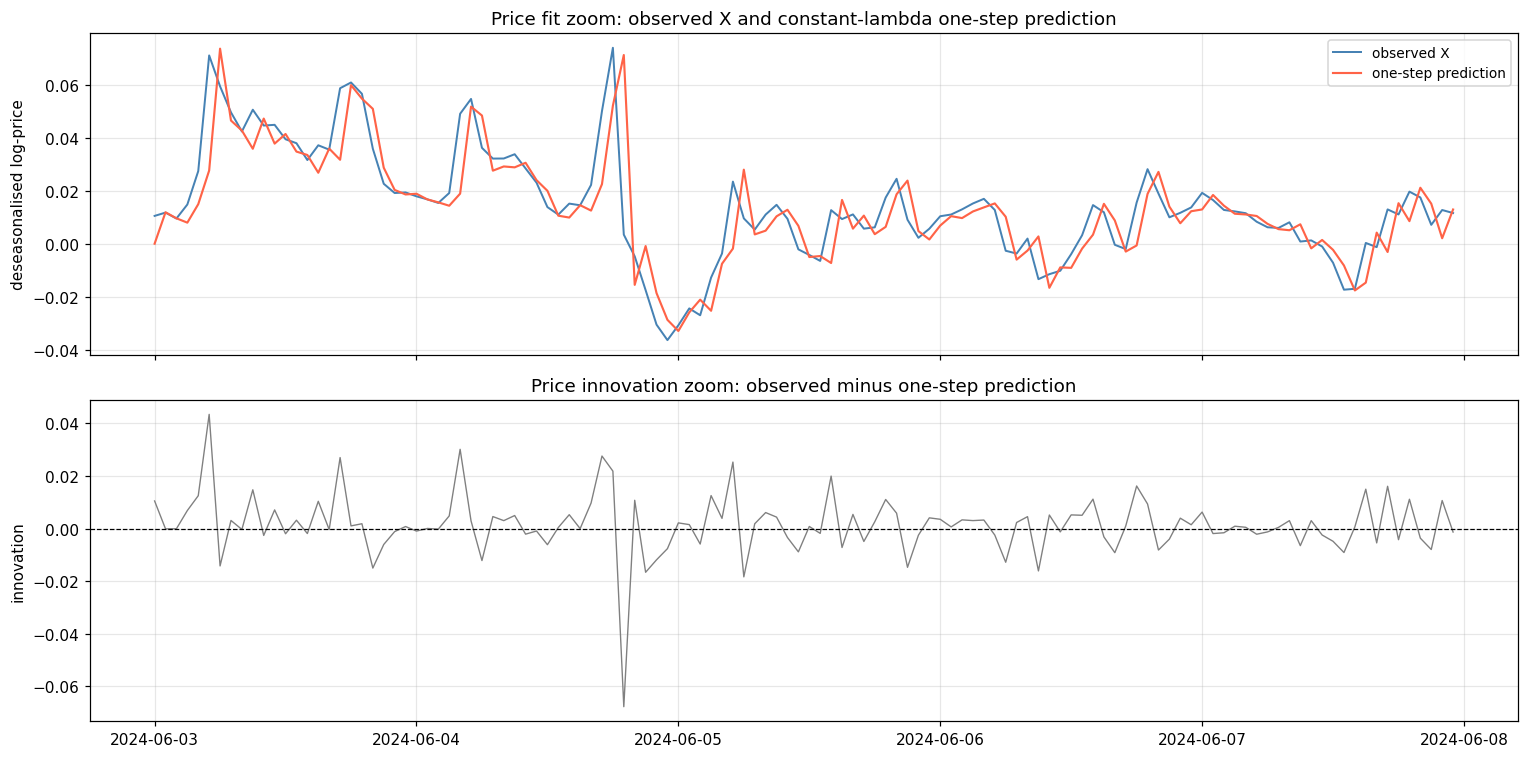

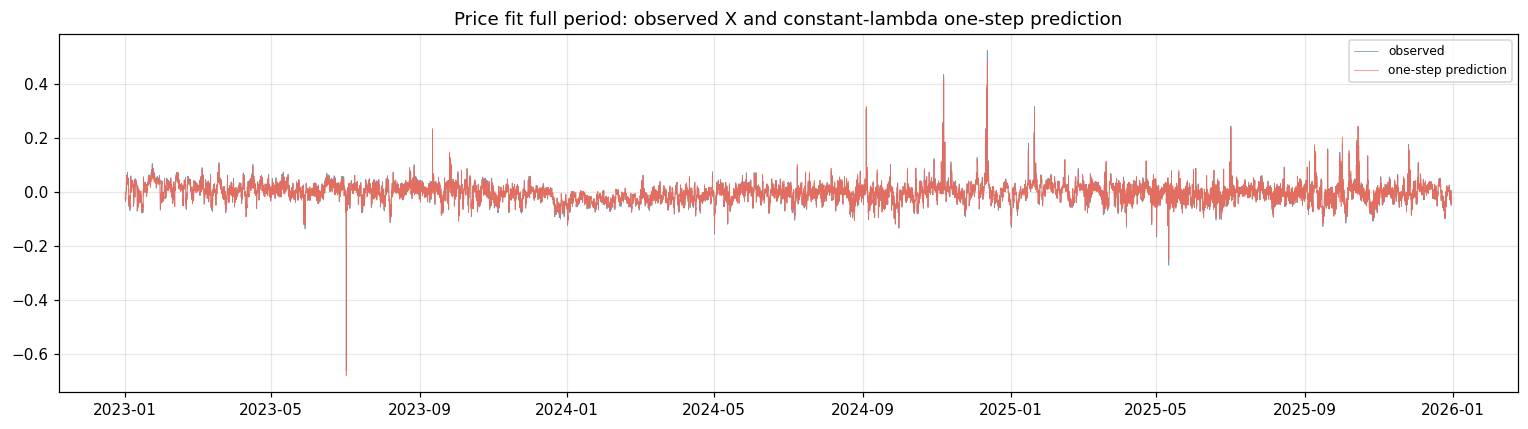

In [37]:
time_c = common_idx

y_pred_X = res_jkf["y_pred"][:, 1]
std_X = np.sqrt(res_jkf["S"][:, 1, 1])

eval_idx = np.arange(1, len(y_X_c))
err_X = y_X_c[eval_idx] - y_pred_X[eval_idx]
rmse = float(np.sqrt(np.mean(err_X**2)))
mae = float(np.mean(np.abs(err_X)))
ss_res = float(np.sum(err_X**2))
ss_tot = float(np.sum((y_X_c[eval_idx] - y_X_c[eval_idx].mean())**2))
r2 = float(1 - ss_res / ss_tot)
price_loglik = float(np.sum(-0.5 * (
    np.log(2 * np.pi * res_jkf["S"][eval_idx, 1, 1])
    + res_jkf["innov"][eval_idx, 1]**2 / res_jkf["S"][eval_idx, 1, 1]
)))

n_params_joint_full = 14
aic_joint_full = -2 * res_jkf["loglik"] + 2 * n_params_joint_full

price_fit_metrics = pd.DataFrame({
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2],
    "joint_loglik": [res_jkf["loglik"]],
    "joint_AIC": [aic_joint_full],
    "price_loglik_contribution": [price_loglik],
}, index=["constant_lambda"])
display(price_fit_metrics.round(8))

mask = (time_c >= pd.Timestamp("2024-06-03", tz="UTC")) & (
    time_c < pd.Timestamp("2024-06-08", tz="UTC")
)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(time_c[mask], y_X_c[mask], lw=1.3, color="steelblue", label="observed X")
axes[0].plot(time_c[mask], y_pred_X[mask], lw=1.4, color="tomato", label="one-step prediction")
axes[0].legend(fontsize=9)
axes[0].set_title("Price fit zoom: observed X and constant-lambda one-step prediction")
axes[0].set_ylabel("deseasonalised log-price")

axes[1].plot(time_c[mask], res_jkf["innov"][mask, 1], lw=0.9, color="gray")
axes[1].axhline(0, ls="--", lw=0.8, color="k")
axes[1].set_title("Price innovation zoom: observed minus one-step prediction")
axes[1].set_ylabel("innovation")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_c, y_X_c, lw=0.5, alpha=0.8, color="steelblue", label="observed")
ax.plot(time_c, y_pred_X, lw=0.5, alpha=0.8, color="tomato", label="one-step prediction")
ax.legend(fontsize=8)
ax.set_title("Price fit full period: observed X and constant-lambda one-step prediction")
plt.tight_layout()
plt.show()


## Joint filter innovations

,mean_z,std_z,skew_z,kurtosis_z,KS_stat,KS_pvalue,LB_p_24h,LB_p_48h,LB_p_168h
temperature,0.004819,1.000071,-0.877634,12.092455,0.076239,0.0,0.0,0.0,0.0
price,-0.000324,0.999004,0.138958,73.985899,0.113493,0.0,0.0,0.0,0.0


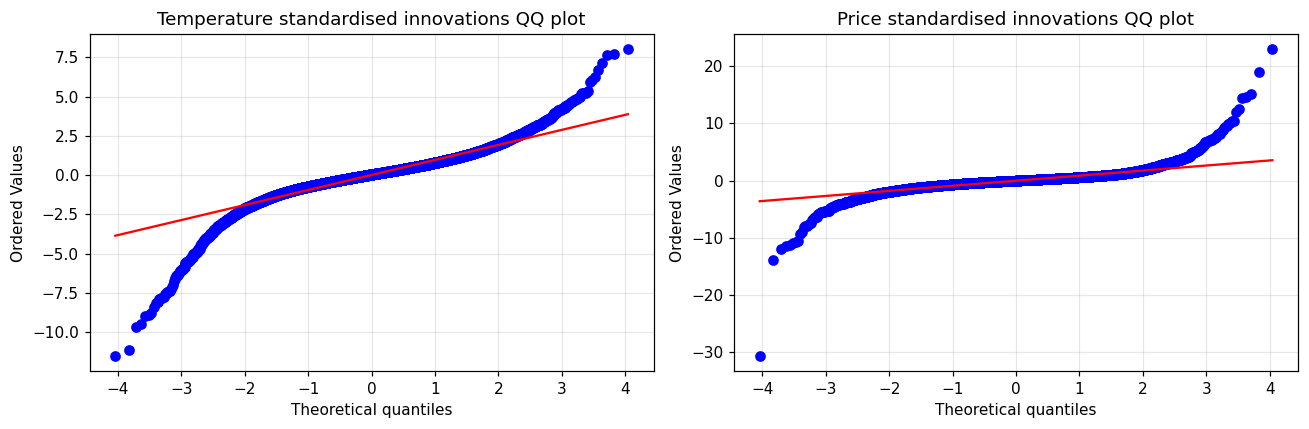

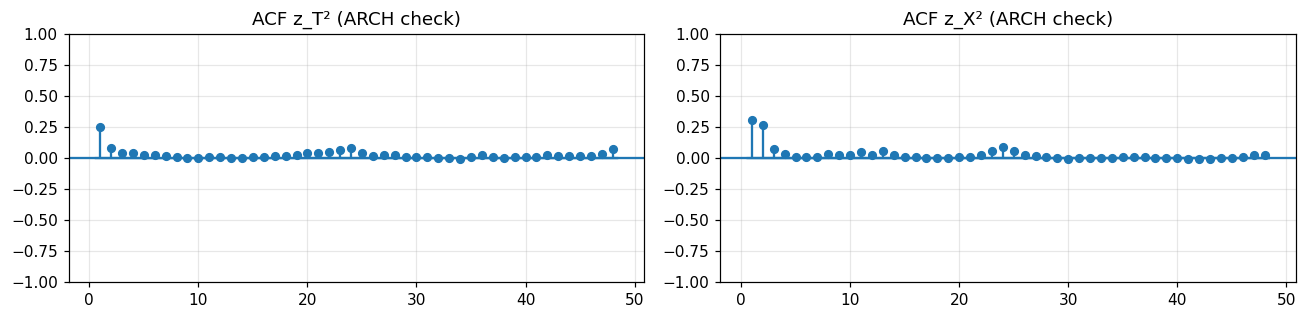

In [38]:
# Temperature innovations
v_T = res_jkf["innov"][:, 0]
z_T = v_T / np.sqrt(res_jkf["S"][:, 0, 0])
z_T_eval = z_T[1:]

sk_T = float(pd.Series(z_T_eval).skew())
ku_T = float(pd.Series(z_T_eval).kurtosis() + 3)
ks_T, ks_p_T = kstest(z_T_eval, 'norm')
lb_T = acorr_ljungbox(z_T_eval, lags=[24, 48, 168], return_df=True)

# Price innovations
v_X = res_jkf["innov"][:, 1]
z_X = v_X / np.sqrt(res_jkf["S"][:, 1, 1])
z_X_eval = z_X[1:]

sk_X = float(pd.Series(z_X_eval).skew())
ku_X = float(pd.Series(z_X_eval).kurtosis() + 3)
ks_X, ks_p_X = kstest(z_X_eval, 'norm')
lb_X = acorr_ljungbox(z_X_eval, lags=[24, 48, 168], return_df=True)

innovation_table = pd.DataFrame({
    "mean_z":     [z_T_eval.mean(),       z_X_eval.mean()],
    "std_z":      [z_T_eval.std(ddof=1),  z_X_eval.std(ddof=1)],
    "skew_z":     [sk_T,                  sk_X],
    "kurtosis_z": [ku_T,                  ku_X],
    "KS_stat":    [ks_T,                  ks_X],
    "KS_pvalue":  [ks_p_T,                ks_p_X],
    "LB_p_24h":   [lb_T.loc[24,  "lb_pvalue"], lb_X.loc[24,  "lb_pvalue"]],
    "LB_p_48h":   [lb_T.loc[48,  "lb_pvalue"], lb_X.loc[48,  "lb_pvalue"]],
    "LB_p_168h":  [lb_T.loc[168, "lb_pvalue"], lb_X.loc[168, "lb_pvalue"]],
}, index=["temperature", "price"])
display(innovation_table.round(8))

# QQ plots for both series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, z_eval, label in zip(axes, [z_T_eval, z_X_eval], ["Temperature", "Price"]):
    probplot(z_eval, dist="norm", plot=ax)
    ax.set_title(f"{label} standardised innovations QQ plot")
plt.tight_layout()
plt.show()

# ACF of squared innovations (ARCH check)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_acf(z_T_eval**2, lags=48, ax=axes[0], title="ACF z_T² (ARCH check)", zero=False)
plot_acf(z_X_eval**2, lags=48, ax=axes[1], title="ACF z_X² (ARCH check)", zero=False)
plt.tight_layout()
plt.show()


## Joint innovations

For the joint Kalman filter,

$$v_k=y_k-\mathbb{E}[y_k\mid\mathcal{F}_{k-1}], \qquad S_k=\operatorname{Var}(v_k\mid\mathcal{F}_{k-1}).$$

Because the coupled model allows $S_{TX,k}\neq 0$, the raw innovations $v_T$ and $v_X$ may be correlated. The direct covariance check is

$$\frac{1}{n}\sum_k v_{T,k}v_{X,k} \approx \frac{1}{n}\sum_k S_{TX,k}.$$


In [22]:
def safe_pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(pearsonr(x, y).statistic)

def safe_spearman_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(spearmanr(x, y).statistic)

def centered_covariance_np(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.mean((x - x.mean()) * (y - y.mean())))

def add_scatter_fit(ax, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 3 or np.std(x, ddof=1) == 0:
        return
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(np.quantile(x, 0.01), np.quantile(x, 0.99), 100)
    ax.plot(xs, intercept + slope * xs, color="black", lw=1.1)

def neutral_scatter(ax, x, y, title, xlabel, ylabel):
    ax.scatter(x, y, s=5, alpha=0.16, color="0.25", edgecolors="none", rasterized=True)
    add_scatter_fit(ax, x, y)
    ax.axhline(0, color="0.75", lw=0.8)
    ax.axvline(0, color="0.75", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def joint_raw_innovation_summary(name, innov, S_arr, start=1):
    """Compare raw joint innovations v_k with their model covariance S_k."""
    v = np.asarray(innov[start:], dtype=float)
    S = np.asarray(S_arr[start:], dtype=float)
    rho_model = S[:, 0, 1] / np.sqrt(S[:, 0, 0] * S[:, 1, 1])
    row = {
        "model": name,
        "n": len(v),
        "mean_v_T": float(v[:, 0].mean()),
        "mean_v_X": float(v[:, 1].mean()),
        "empirical_E_vT_vX": float(np.mean(v[:, 0] * v[:, 1])),
        "empirical_centered_cov_v": centered_covariance_np(v[:, 0], v[:, 1]),
        "mean_model_S_TX": float(S[:, 0, 1].mean()),
        "raw_cov_error": float(np.mean(v[:, 0] * v[:, 1]) - S[:, 0, 1].mean()),
        "empirical_corr_v": safe_pearson_r(v[:, 0], v[:, 1]),
        "mean_model_corr": float(rho_model.mean()),
    }
    return row, v, S

def marginal_raw_innovation_summary(name, v_T, v_X):
    """Separate marginal filters do not define S_TX; zero is the independence benchmark."""
    v = np.column_stack([np.asarray(v_T, dtype=float), np.asarray(v_X, dtype=float)])
    row = {
        "model": name,
        "n": len(v),
        "mean_v_T": float(v[:, 0].mean()),
        "mean_v_X": float(v[:, 1].mean()),
        "empirical_E_vT_vX": float(np.mean(v[:, 0] * v[:, 1])),
        "empirical_centered_cov_v": centered_covariance_np(v[:, 0], v[:, 1]),
        "mean_model_S_TX": 0.0,
        "raw_cov_error": float(np.mean(v[:, 0] * v[:, 1])),
        "empirical_corr_v": safe_pearson_r(v[:, 0], v[:, 1]),
        "mean_model_corr": 0.0,
    }
    return row, v


joint_row, v_joint, S_joint_eval = joint_raw_innovation_summary(
    "constant_lambda", res_jkf["innov"], res_jkf["S"], start=1
)
joint_innovation_covariance = pd.DataFrame([joint_row]).set_index("model")
display(joint_innovation_covariance.round(8))


,n,mean_v_T,mean_v_X,empirical_E_vT_vX,empirical_centered_cov_v,mean_model_S_TX,raw_cov_error,empirical_corr_v,mean_model_corr
model,,,,,,,,,
constant_lambda,26280,0.002822,-0.000004,-0.000211,-0.000211,-0.000222,0.000011,-0.029252,-0.018887


## Residual covariance

For the structural coupling check, the residuals are CARMA state residuals:

$$R_T(k)=Z_T(k+1)-\exp(A_T h)Z_T(k), \qquad R_X(k)=Z_X(k+1)-\exp(A_X h)Z_X(k).$$

The observable projections are $r_T(k)=b_T'R_T(k)$ and $r_X(k)=b_X'R_X(k)$. The coupling model targets

$$\operatorname{Cov}(r_T,r_X)=\lambda\, b_T'K_{TX}b_X.$$


In [15]:
x_jf = res_jkf["x_filt"]
R_T_jf = np.zeros((len(x_jf) - 1, p_T))
R_X_jf = np.zeros((len(x_jf) - 1, p_X))
F_cache = {}

for k in range(len(x_jf) - 1):
    dt = float((time_c[k + 1] - time_c[k]) / pd.Timedelta(hours=1))
    if dt not in F_cache:
        F_cache[dt] = (expm(A_T * dt), expm(A_X * dt))
    FT_dt, FX_dt = F_cache[dt]
    R_T_jf[k] = x_jf[k + 1, :p_T] - FT_dt @ x_jf[k, :p_T]
    R_X_jf[k] = x_jf[k + 1, p_T:] - FX_dt @ x_jf[k, p_T:]

r_T_obs = R_T_jf @ b_T
r_X_obs = R_X_jf @ b_X

emp_cov = float(np.mean((r_T_obs - r_T_obs.mean()) * (r_X_obs - r_X_obs.mean())))
emp_cov_uncentered = float(np.mean(r_T_obs * r_X_obs))
model_cov = float(lambda_hat * denom_lam)
rel_err = float(abs(emp_cov - model_cov) / max(abs(model_cov), 1e-300) * 100)

covariance_table = pd.DataFrame({
    "empirical_cov_centered": [emp_cov],
    "empirical_cov_uncentered": [emp_cov_uncentered],
    "model_cov": [model_cov],
    "relative_error_pct": [rel_err],
    "mean_r_T": [float(r_T_obs.mean())],
    "mean_r_X": [float(r_X_obs.mean())],
}, index=["observable_state_residuals"])
display(covariance_table.round(8))


,empirical_cov_centered,empirical_cov_uncentered,model_cov,relative_error_pct,mean_r_T,mean_r_X
observable_state_residuals,-0.000211,-0.000211,-0.000208,1.425214,0.002822,-0.000004


## Scatter plots

The scatter plots use three different objects. One-step predictions show the fitted conditional means. Marginal projected state residuals show the covariance object used to estimate $\lambda$. Raw joint innovations are compared with the model-implied covariance $S_{TX,k}$.


,sample,n,pearson_r,spearman_r
0,observed_values,26280,-0.049760,-0.045708
1,one_step_predictions,26280,-0.043789,-0.040152
2,marginal_projected_state_residuals,26280,-0.028846,-0.044737
3,joint_raw_innovations,26280,-0.029244,-0.050320


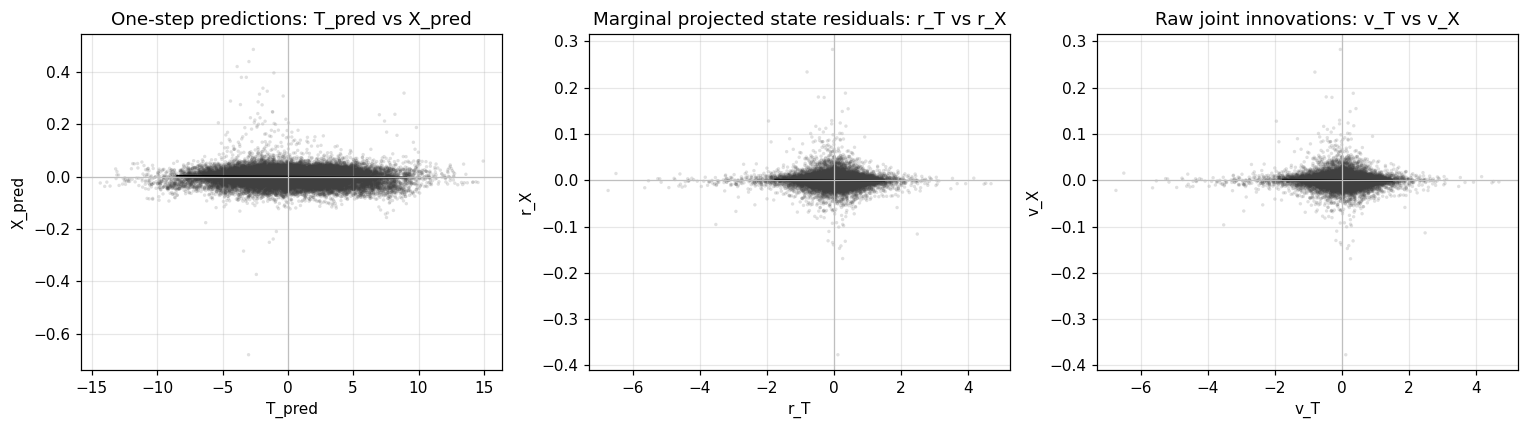

In [16]:
def safe_pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(pearsonr(x, y).statistic)

def safe_spearman_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(spearmanr(x, y).statistic)

def centered_covariance_np(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.mean((x - x.mean()) * (y - y.mean())))

def add_scatter_fit(ax, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 3 or np.std(x, ddof=1) == 0:
        return
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(np.quantile(x, 0.01), np.quantile(x, 0.99), 100)
    ax.plot(xs, intercept + slope * xs, color="black", lw=1.1)

def neutral_scatter(ax, x, y, title, xlabel, ylabel):
    ax.scatter(x, y, s=5, alpha=0.16, color="0.25", edgecolors="none", rasterized=True)
    add_scatter_fit(ax, x, y)
    ax.axhline(0, color="0.75", lw=0.8)
    ax.axvline(0, color="0.75", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def corr_row(name, x, y):
    return {
        "sample": name,
        "n": len(x),
        "pearson_r": safe_pearson_r(x, y),
        "spearman_r": safe_spearman_r(x, y),
    }

pred_eval = res_jkf["y_pred"][1:]
scatter_corr = pd.DataFrame([
    corr_row("observed_values", y_T_c[1:], y_X_c[1:]),
    corr_row("one_step_predictions", pred_eval[:, 0], pred_eval[:, 1]),
    corr_row("marginal_projected_state_residuals", r_T_marginal_obs, r_X_marginal_obs),
    corr_row("joint_raw_innovations", v_joint[:, 0], v_joint[:, 1]),
])
display(scatter_corr.round(8))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
neutral_scatter(
    axes[0],
    pred_eval[:, 0],
    pred_eval[:, 1],
    "One-step predictions: T_pred vs X_pred",
    "T_pred",
    "X_pred",
)
neutral_scatter(
    axes[1],
    r_T_marginal_obs,
    r_X_marginal_obs,
    "Marginal projected state residuals: r_T vs r_X",
    "r_T",
    "r_X",
)
neutral_scatter(
    axes[2],
    v_joint[:, 0],
    v_joint[:, 1],
    "Raw joint innovations: v_T vs v_X",
    "v_T",
    "v_X",
)
plt.tight_layout()
plt.show()


## Price shock distribution


,skewness,kurtosis,Gaussian_AIC,NIG_AIC,delta_AIC_NIG_minus_Gaussian,temp_variance_share_pct
dL_X,0.411225,84.305102,51010.212699,37420.029295,-13590.183404,0.340458


,a,b,loc,scale
NIG,0.32884,-0.031766,0.032524,0.334887


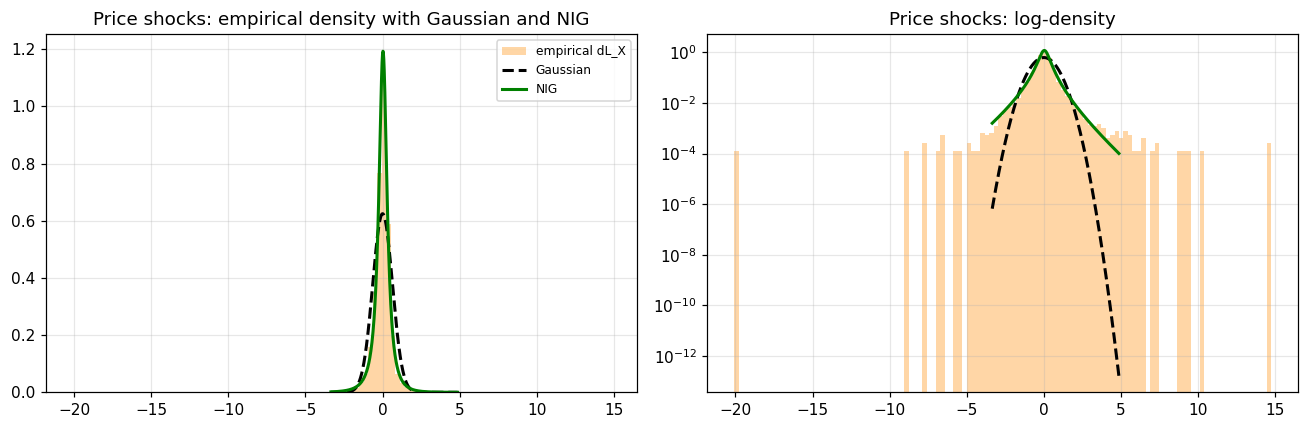

In [23]:
sk_X = float(pd.Series(dL_X).skew())
ku_X = float(pd.Series(dL_X).kurtosis() + 3)

price_shock_table = pd.DataFrame({
    "skewness": [sk_X],
    "kurtosis": [ku_X],
    "Gaussian_AIC": [aic_g_X],
    "NIG_AIC": [aic_nig_X],
    "delta_AIC_NIG_minus_Gaussian": [aic_nig_X - aic_g_X if nig_ok_X else np.nan],
    "temp_variance_share_pct": [temp_share],
}, index=["dL_X"])
display(price_shock_table.round(6))
if nig_ok_X:
    display(pd.DataFrame({
        "a": [ax_n],
        "b": [bx_n],
        "loc": [lx_n],
        "scale": [sx_n],
    }, index=["NIG"]).round(6))

x_plot = np.linspace(np.quantile(dL_X, 0.001), np.quantile(dL_X, 0.999), 600)
gauss_pdf = norm.pdf(x_plot, mu_g, sg)
nig_pdf = norminvgauss.pdf(x_plot, ax_n, bx_n, loc=lx_n, scale=sx_n) if nig_ok_X else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dL_X, bins=120, density=True, color="darkorange", alpha=0.35, label="empirical dL_X")
axes[0].plot(x_plot, gauss_pdf, "k--", lw=2, label="Gaussian")
if nig_ok_X:
    axes[0].plot(x_plot, nig_pdf, "g-", lw=2, label="NIG")
axes[0].legend(fontsize=8)
axes[0].set_title("Price shocks: empirical density with Gaussian and NIG")

axes[1].hist(dL_X, bins=120, density=True, color="darkorange", alpha=0.35, log=True)
axes[1].plot(x_plot, np.maximum(gauss_pdf, 1e-300), "k--", lw=2)
if nig_ok_X:
    axes[1].plot(x_plot, np.maximum(nig_pdf, 1e-300), "g-", lw=2)
axes[1].set_title("Price shocks: log-density")

plt.tight_layout()
plt.show()


## Monte Carlo simulation parameters


In [24]:
import json


def as_json_array(x):
    return json.dumps(np.asarray(x, dtype=float).tolist())


def get_param(params_df, series, model, parameter):
    row = params_df[
        (params_df["series"] == series)
        & (params_df["model"] == model)
        & (params_df["parameter"] == parameter)
    ]
    if row.empty:
        raise KeyError((series, model, parameter))
    return float(row["value"].iloc[0])


idio_series = "price_idiosyncratic_driver"

mc_final_parameters = pd.DataFrame([
    {"component": "global", "parameter": "model_family", "value": "coupled_CARMA"},
    {"component": "global", "parameter": "dt_hours", "value": h},

    {"component": "temperature_state", "parameter": "A_T", "value": as_json_array(A_T)},
    {"component": "temperature_state", "parameter": "b_T", "value": as_json_array(b_T)},
    {"component": "temperature_state", "parameter": "e_T", "value": as_json_array(e_T)},
    {"component": "temperature_state", "parameter": "sigma_T", "value": sigma_T},

    {"component": "temperature_driver", "parameter": "distribution", "value": "Gaussian"},
    {"component": "temperature_driver", "parameter": "mu", "value": mu_T},
    {"component": "temperature_driver", "parameter": "sigma", "value": sig_T},

    {"component": "price_state", "parameter": "A_X", "value": as_json_array(A_X)},
    {"component": "price_state", "parameter": "b_X", "value": as_json_array(b_X)},
    {"component": "price_state", "parameter": "e_X", "value": as_json_array(e_X)},
    {"component": "price_state", "parameter": "lambda", "value": lambda_hat},
    {"component": "price_state", "parameter": "sigma_J", "value": sigma_J},

    {"component": "price_idiosyncratic_driver", "parameter": "distribution", "value": "NIG"},
    {"component": "price_idiosyncratic_driver", "parameter": "alpha", "value": get_param(driver_params, idio_series, "NIG", "alpha")},
    {"component": "price_idiosyncratic_driver", "parameter": "beta", "value": get_param(driver_params, idio_series, "NIG", "beta")},
    {"component": "price_idiosyncratic_driver", "parameter": "delta", "value": get_param(driver_params, idio_series, "NIG", "delta")},
    {"component": "price_idiosyncratic_driver", "parameter": "mu", "value": get_param(driver_params, idio_series, "NIG", "mu")},
])

display(mc_final_parameters)
mc_final_parameters.to_csv("../data/levy/carma_montecarlo_final_parameters.csv", index=False)
mc_final_parameters.to_csv("../data/levy/carma_montecarlo_driver_params.csv", index=False)


,component,parameter,value
0,global,model_family,coupled_CARMA
1,global,dt_hours,1.0
2,temperature_state,A_T,"[[0.0, 1.0], [-0.02473622057743, -0.8346025547..."
3,temperature_state,b_T,"[1.0, 0.584420888567256]"
4,temperature_state,e_T,"[0.0, 1.0]"
5,temperature_state,sigma_T,0.769633
6,temperature_driver,distribution,Gaussian
7,temperature_driver,mu,0.004627
8,temperature_driver,sigma,0.961933
9,price_state,A_X,"[[0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [-0.1611635..."
